In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import random
from pathlib import Path
from collections import defaultdict

# ── Charger les données des phases précédentes ───────────
scores_path = Path("C:/SmartMeal/data/usda/health_scores.csv")
combos_path = Path("C:/SmartMeal/data/combinations/food_combinations.csv")

df_scores = pd.read_csv(scores_path)
df_combos = pd.read_csv(combos_path)

print("✅ Imports OK")
print(f"📊 Aliments chargés    : {len(df_scores)}")
print(f"📊 Combinaisons créées : {len(df_combos)}")
print(f"\nAliments disponibles : {df_scores['class_name'].tolist()}")

✅ Imports OK
📊 Aliments chargés    : 10
📊 Combinaisons créées : 20

Aliments disponibles : ['grilled_salmon', 'steak', 'hamburger', 'pizza', 'omelette', 'caesar_salad', 'sushi', 'apple_pie', 'ice_cream', 'bibimbap']


In [2]:
class MealEnvironment:
    """
    Environnement RL pour optimiser un repas.
    
    État   : liste des aliments déjà sélectionnés
    Action : ajouter un aliment au repas
    Reward : score de santé + bonus compatibilité
    Goal   : construire un repas avec score > 70/100
    """
    
    def __init__(self, df_scores, df_combos, max_items=3):
        self.foods     = df_scores["class_name"].tolist()
        self.scores    = dict(zip(df_scores["class_name"], df_scores["score"]))
        self.max_items = max_items
        self.n_actions = len(self.foods)
        
        # Construire le dictionnaire de compatibilité
        self.compatibility = {}
        for _, row in df_combos.iterrows():
            key = tuple(sorted([row["food_1"], row["food_2"]]))
            self.compatibility[key] = row["compatible"]
        
        self.reset()
    
    def reset(self):
        self.meal      = []
        self.done      = False
        self.total_reward = 0
        return self._get_state()
    
    def _get_state(self):
        state = np.zeros(self.n_actions)
        for food in self.meal:
            if food in self.foods:
                state[self.foods.index(food)] = 1
        return state
    
    def _get_compatibility_bonus(self, new_food):
        bonus = 0
        for existing in self.meal:
            key = tuple(sorted([existing, new_food]))
            if key in self.compatibility:
                bonus += 15 if self.compatibility[key] else -20
        return bonus
    
    def step(self, action):
        food = self.foods[action]
        
        # Pénalité si aliment déjà dans le repas
        if food in self.meal:
            return self._get_state(), -10, self.done, {"info": "déjà sélectionné"}
        
        self.meal.append(food)
        
        # Calcul du reward
        nutrition_reward   = (self.scores[food] - 50) / 10
        compatibility_bonus = self._get_compatibility_bonus(food)
        reward             = nutrition_reward + compatibility_bonus
        
        self.total_reward += reward
        
        # Fin si repas complet
        if len(self.meal) >= self.max_items:
            self.done = True
            # Bonus final si score moyen > 70
            avg_score = np.mean([self.scores[f] for f in self.meal])
            if avg_score >= 70:
                reward += 30
        
        return self._get_state(), reward, self.done, {
            "meal"       : self.meal.copy(),
            "avg_score"  : np.mean([self.scores[f] for f in self.meal]),
            "food_added" : food
        }
    
    def get_meal_summary(self):
        if not self.meal:
            return {}
        avg_score = np.mean([self.scores[f] for f in self.meal])
        return {
            "meal"      : self.meal,
            "avg_score" : round(avg_score, 1),
            "total_reward" : round(self.total_reward, 2)
        }

# ── Test de l'environnement ───────────────────────────────
env = MealEnvironment(df_scores, df_combos, max_items=3)
state = env.reset()

print("✅ Environnement RL créé")
print(f"   Actions possibles : {env.n_actions} aliments")
print(f"   Taille état       : {len(state)}")
print(f"   Objectif          : construire un repas score > 70/100")
print(f"\n🧪 Test action aléatoire :")
for i in range(3):
    action = random.randint(0, env.n_actions - 1)
    state, reward, done, info = env.step(action)
    print(f"   {i+1}. {info.get('food_added','?'):20s} → reward: {reward:.1f}")
print(f"   Repas final : {env.get_meal_summary()}")

✅ Environnement RL créé
   Actions possibles : 10 aliments
   Taille état       : 10
   Objectif          : construire un repas score > 70/100

🧪 Test action aléatoire :
   1. sushi                → reward: 0.0
   2. grilled_salmon       → reward: 18.0
   3. hamburger            → reward: 2.0
   Repas final : {'meal': ['sushi', 'grilled_salmon', 'hamburger'], 'avg_score': np.float64(66.7), 'total_reward': 20.0}


In [3]:
class QLearningAgent:
    """
    Agent Q-Learning pour optimiser les repas.
    Apprend quelle action prendre dans chaque état.
    """
    
    def __init__(self, n_states, n_actions, lr=0.1, gamma=0.9,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.05):
        self.n_actions     = n_actions
        self.lr            = lr
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min
        
        # Table Q — utilise un dict pour états discrets
        self.q_table = defaultdict(lambda: np.zeros(n_actions))
    
    def get_action(self, state):
        # Exploration vs Exploitation (epsilon-greedy)
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)  # exploration
        
        state_key = tuple(state.astype(int))
        return np.argmax(self.q_table[state_key])           # exploitation
    
    def update(self, state, action, reward, next_state):
        state_key      = tuple(state.astype(int))
        next_state_key = tuple(next_state.astype(int))
        
        # Formule Q-Learning
        current_q  = self.q_table[state_key][action]
        max_next_q = np.max(self.q_table[next_state_key])
        new_q      = current_q + self.lr * (reward + self.gamma * max_next_q - current_q)
        
        self.q_table[state_key][action] = new_q
    
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


agent = QLearningAgent(
    n_states  = 2 ** len(df_scores),
    n_actions = len(df_scores)
)

print("✅ Agent Q-Learning créé")
print(f"   Learning rate  : {agent.lr}")
print(f"   Gamma          : {agent.gamma}")
print(f"   Epsilon start  : {agent.epsilon}")
print(f"   Epsilon min    : {agent.epsilon_min}")

✅ Agent Q-Learning créé
   Learning rate  : 0.1
   Gamma          : 0.9
   Epsilon start  : 1.0
   Epsilon min    : 0.05


In [4]:
N_EPISODES  = 2000
rewards_log = []
scores_log  = []
best_meals  = []

print(f"🚀 Entraînement RL — {N_EPISODES} épisodes...\n")

for episode in range(N_EPISODES):
    state = env.reset()
    episode_reward = 0
    
    while not env.done:
        action               = agent.get_action(state)
        next_state, reward, done, info = env.step(action)
        agent.update(state, action, reward, next_state)
        state          = next_state
        episode_reward += reward
    
    agent.decay_epsilon()
    
    summary = env.get_meal_summary()
    rewards_log.append(episode_reward)
    scores_log.append(summary.get("avg_score", 0))
    
    # Garder les meilleurs repas
    if summary.get("avg_score", 0) >= 70:
        best_meals.append(summary.copy())
    
    # Afficher la progression
    if (episode + 1) % 200 == 0:
        avg_reward = np.mean(rewards_log[-200:])
        avg_score  = np.mean(scores_log[-200:])
        print(f"  Épisode {episode+1:4d}/{N_EPISODES} | "
              f"Reward moy: {avg_reward:6.2f} | "
              f"Score moy: {avg_score:.1f}/100 | "
              f"ε: {agent.epsilon:.3f}")

print(f"\n✅ Entraînement terminé !")
print(f"   Meilleurs repas trouvés (score ≥ 70) : {len(best_meals)}")
if best_meals:
    best = max(best_meals, key=lambda x: x["avg_score"])
    print(f"   🏆 Meilleur repas : {best['meal']} → {best['avg_score']}/100")

🚀 Entraînement RL — 2000 épisodes...

  Épisode  200/2000 | Reward moy:  20.68 | Score moy: 63.8/100 | ε: 0.367
  Épisode  400/2000 | Reward moy:  43.66 | Score moy: 67.0/100 | ε: 0.135
  Épisode  600/2000 | Reward moy:  57.88 | Score moy: 68.9/100 | ε: 0.050
  Épisode  800/2000 | Reward moy:  63.28 | Score moy: 69.8/100 | ε: 0.050
  Épisode 1000/2000 | Reward moy:  64.78 | Score moy: 69.8/100 | ε: 0.050
  Épisode 1200/2000 | Reward moy:  61.37 | Score moy: 69.5/100 | ε: 0.050
  Épisode 1400/2000 | Reward moy:  63.22 | Score moy: 69.6/100 | ε: 0.050
  Épisode 1600/2000 | Reward moy:  61.36 | Score moy: 69.5/100 | ε: 0.050
  Épisode 1800/2000 | Reward moy:  62.48 | Score moy: 69.5/100 | ε: 0.050
  Épisode 2000/2000 | Reward moy:  61.92 | Score moy: 69.5/100 | ε: 0.050

✅ Entraînement terminé !
   Meilleurs repas trouvés (score ≥ 70) : 1658
   🏆 Meilleur repas : ['grilled_salmon', 'steak', 'hamburger'] → 74.0/100


C:\Users\pc\AppData\Local\Temp\ipykernel_16568\2068760057.py:26: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_16568\2068760057.py:26: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_16568\2068760057.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("C:/SmartMeal/reports/rl_training.png", dpi=150)
C:\Users\pc\AppData\Local\Temp\ipykernel_16568\2068760057.py:27: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.savefig("C:/SmartMeal/reports/rl_training.png", dpi=150)
C:\SmartMeal\smartmeal_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\SmartMeal\smartmeal_env\Lib

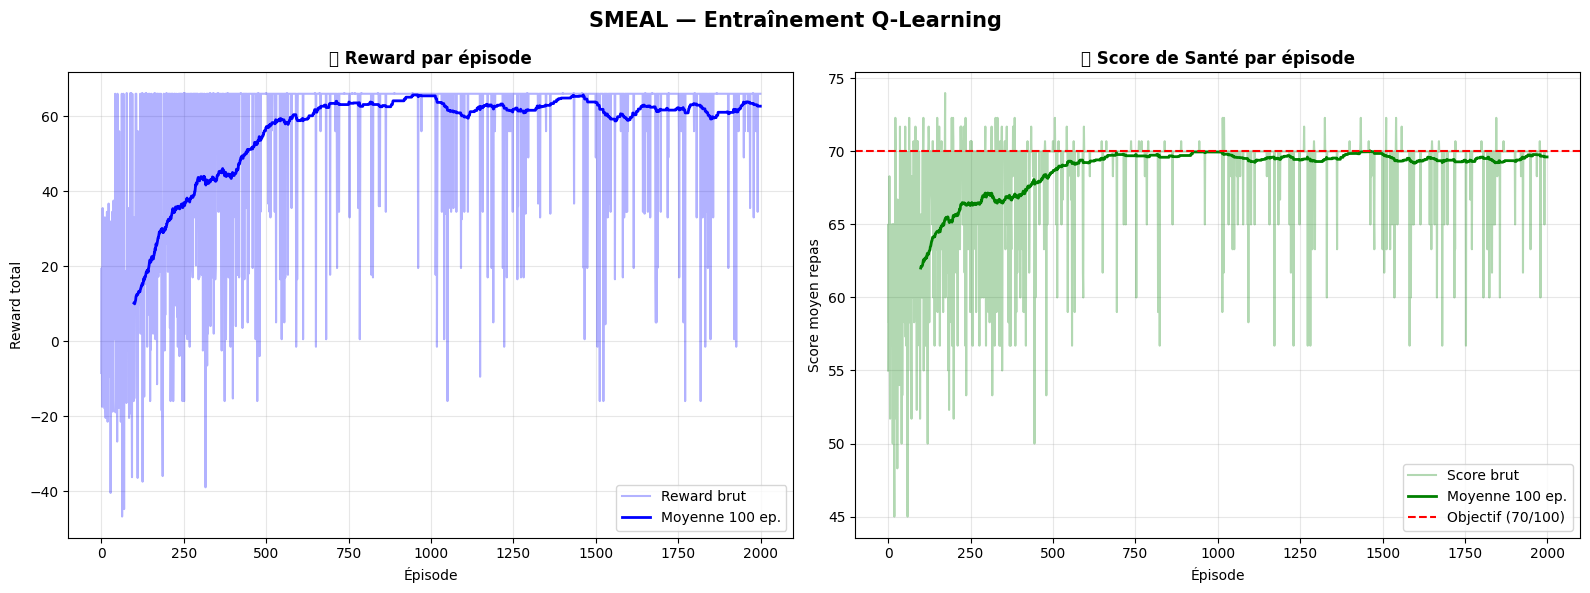


✅ Résultats RL sauvegardés : C:\SmartMeal\models\rl_results.json

📊 Résumé final :
   n_episodes                          : 2000
   final_epsilon                       : 0.05
   avg_reward_final_200                : 61.92
   avg_score_final_200                 : 69.5
   best_meals_count                    : 1658
   best_meal                           : {'meal': ['grilled_salmon', 'steak', 'hamburger'], 'avg_score': np.float64(74.0), 'total_reward': -12.8}


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Courbe rewards ────────────────────────────────────────
window = 100
smoothed_rewards = pd.Series(rewards_log).rolling(window).mean()
axes[0].plot(rewards_log,       alpha=0.3, color="blue", label="Reward brut")
axes[0].plot(smoothed_rewards,  color="blue", linewidth=2, label=f"Moyenne {window} ep.")
axes[0].set_title("📈 Reward par épisode", fontweight="bold")
axes[0].set_xlabel("Épisode")
axes[0].set_ylabel("Reward total")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Courbe scores ─────────────────────────────────────────
smoothed_scores = pd.Series(scores_log).rolling(window).mean()
axes[1].plot(scores_log,       alpha=0.3, color="green", label="Score brut")
axes[1].plot(smoothed_scores,  color="green", linewidth=2, label=f"Moyenne {window} ep.")
axes[1].axhline(y=70, color="red", linestyle="--", label="Objectif (70/100)")
axes[1].set_title("🏥 Score de Santé par épisode", fontweight="bold")
axes[1].set_xlabel("Épisode")
axes[1].set_ylabel("Score moyen repas")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("SMEAL — Entraînement Q-Learning", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("C:/SmartMeal/reports/rl_training.png", dpi=150)
plt.show()

# ── Sauvegarder les résultats ─────────────────────────────
rl_results = {
    "n_episodes"   : N_EPISODES,
    "final_epsilon": round(agent.epsilon, 4),
    "avg_reward_final_200" : round(float(np.mean(rewards_log[-200:])), 2),
    "avg_score_final_200"  : round(float(np.mean(scores_log[-200:])),  2),
    "best_meals_count"     : len(best_meals),
    "best_meal"            : max(best_meals, key=lambda x: x["avg_score"]) if best_meals else {}
}

rl_path = Path("C:/SmartMeal/models/rl_results.json")
with open(rl_path, "w") as f:
    json.dump(rl_results, f, indent=2)

print(f"\n✅ Résultats RL sauvegardés : {rl_path}")
print(f"\n📊 Résumé final :")
for k, v in rl_results.items():
    print(f"   {k:35s} : {v}")